<a href="https://colab.research.google.com/github/SaidCondoriRomero/BibliotecaLAB8/blob/master/Laboratorios/Laboratorio_5/Laboratorio_5_PyTorch_multivarable_grafico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 5 — Clasificación Multiclase con PyTorch
## Reconocimiento de Caracteres Devanagari (44 clases)

**Curso:** SIS-420 Inteligencia Artificial  
**Dataset:** Devanagari Handwritten Character Dataset (Drive)  
**Fuente original (Lab 5:** One-vs-All con Regresión Logística regularizada (NumPy/SciPy)  
**Este cuadernillo:** Misma tarea, resuelta con Red Neuronal en **PyTorch**







In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# ── Core PyTorch ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Ciencia de datos
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from PIL import Image
%matplotlib inline
pyplot.rcParams['figure.facecolor'] = 'white'
pyplot.rcParams['grid.alpha'] = 0.3

# ── Métricas
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)


# ── Semillas para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print('✓ Importaciones completadas')

✓ Importaciones completadas


In [4]:
# Detectar GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"{'='*50}")
print(f'Dispositivo disponible: {device.upper()}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('⚠️  GPU NO disponible. El entrenamiento será más lento.')
print(f"{'='*50}")

Dispositivo disponible: CUDA
GPU: Tesla T4
Memoria GPU: 15.64 GB


## Carga y Preprocesamiento de Imágenes

Mismo proceso que el Lab 6 original:
- Leer imágenes 32×32 en escala de grises → aplanar a 1024 features
- Reasignar etiquetas 0–43 sin huecos
- Balancear clases (888 ejemplos por clase = el mínimo del dataset)
- Split 80/20, normalización Z-score solo con train

In [5]:
# ── 1.1 Carga de imágenes — igual que Lab 6 ───────────────────────────────────
ruta_train = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/DevanagariHandwrittenCharacterDataset/Train'
ruta_test  = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/DevanagariHandwrittenCharacterDataset/Test'

imagenes = []
etiquetas = []

clases = sorted(os.listdir(ruta_train))
clase_a_numero = {clase: i for i, clase in enumerate(clases)}

print(f'Número de carpetas detectadas: {len(clases)}')
print('Cargando imágenes...')

for carpeta in [ruta_train, ruta_test]:
    for clase in clases:
        ruta_clase = os.path.join(carpeta, clase)
        if not os.path.isdir(ruta_clase):
            continue
        for archivo in os.listdir(ruta_clase):
            ruta_img = os.path.join(ruta_clase, archivo)
            img = Image.open(ruta_img).convert('L')  # escala de grises
            img = img.resize((32, 32))
            imagenes.append(np.array(img).flatten())  # 1024 features
            etiquetas.append(clase_a_numero[clase])

X = np.array(imagenes)
y = np.array(etiquetas)

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')

Número de carpetas detectadas: 46
Cargando imágenes...
Shape X: (74904, 1024)
Shape y: (74904,)


In [6]:
# ── 1.2 Reasignar etiquetas 0–43 sin huecos — igual que Lab 6 ────────────────
clases_unicas = sorted(np.unique(y))
reasignar = {viejo: nuevo for nuevo, viejo in enumerate(clases_unicas)}
y = np.array([reasignar[etiqueta] for etiqueta in y])

num_labels = len(np.unique(y))

print(f'Clases únicas: {np.unique(y)}')
print(f'Número de clases: {num_labels}')

Clases únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]
Número de clases: 44


In [7]:
# ── 1.3 Balanceo de clases — 888 ejemplos por clase (igual que Lab 6) ─────────
np.random.seed(42)
indices_balanceados = []

for c in range(num_labels):
    idx = np.where(y == c)[0]
    idx_muestra = np.random.choice(idx, 888, replace=False)
    indices_balanceados.append(idx_muestra)

indices_balanceados = np.concatenate(indices_balanceados)
np.random.shuffle(indices_balanceados)

X = X[indices_balanceados]
y = y[indices_balanceados]

print(f'Shape X balanceado: {X.shape}')
print(f'Total ejemplos: {len(y)}')
print(f'Ejemplos por clase: {np.unique(y, return_counts=True)[1]}')

Shape X balanceado: (39072, 1024)
Total ejemplos: 39072
Ejemplos por clase: [888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888
 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888
 888 888 888 888 888 888 888 888]


In [8]:
# ── 1.4 División 80/20 y normalización Z-score ────────────────────────────────
# CRÍTICO: mu y sigma se calculan SOLO con train, luego se aplican a test
m, n = X.shape
np.random.seed(42)
indices = np.random.permutation(m)
corte   = int(0.8 * m)

X_train_raw = X[indices[:corte]]
y_train     = y[indices[:corte]]
X_test_raw  = X[indices[corte:]]
y_test      = y[indices[corte:]]

# Normalización — solo estadísticas de train (sin data leakage)
mu    = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw,  axis=0)
sigma[sigma == 0] = 1

X_train_norm = (X_train_raw - mu) / sigma
X_test_norm  = (X_test_raw  - mu) / sigma

print(f'Train: {X_train_norm.shape[0]:,} ejemplos (80%)')
print(f'Test:  {X_test_norm.shape[0]:,} ejemplos (20%)')
print('✓ Normalización Z-score aplicada (sin data leakage)')

Train: 31,257 ejemplos (80%)
Test:  7,815 ejemplos (20%)
✓ Normalización Z-score aplicada (sin data leakage)


In [9]:
# ── 1.5 Nombres de las 44 clases (igual que Lab 6) ───────────────────────────
nombres_clases = [
    'ka','kha','ga','gha','kna',
    'cha','chha','ja','jha','yna',
    'taamatar','thaa','daa','dhaa','adna',
    'tabala','tha','da','dha','na',
    'pa','pha','ba','bha','ma',
    'yaw','ra','la','waw','motosaw',
    'petchiryakha','patalosaw','ha','chhya','tra',
    'gya','digit_0','digit_1','digit_2','digit_3',
    'digit_4','digit_5','digit_6','digit_7'
]

print(f'Total de clases nombradas: {len(nombres_clases)}')
print(f'Primera clase: {nombres_clases[0]}  |  Última: {nombres_clases[-1]}')

Total de clases nombradas: 44
Primera clase: ka  |  Última: digit_7


## Dataset y DataLoader (cuadernillo 03)

Para imágenes usamos `Dataset` personalizado con `__init__`, `__len__` y `__getitem__`.

Diferencia clave con el Lab 6 original:  
- Lab 6: itera manualmente sobre arrays con `scipy.optimize` (un clasificador por clase)
- PyTorch: itera en mini-batches automáticamente con `DataLoader`

In [10]:
# ── 2.1 Dataset personalizado (patrón del cuadernillo 03) ─────────────────────
class DevanagariDataset(Dataset):
    """Dataset de caracteres Devanagari: 44 clases, imágenes 32x32 aplanadas."""

    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        # y debe ser long (enteros) para CrossEntropyLoss
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]


train_dataset = DevanagariDataset(X_train_norm, y_train)
test_dataset  = DevanagariDataset(X_test_norm,  y_test)

print(f'✓ Datasets creados')
print(f'  Train: {len(train_dataset):,} ejemplos')
print(f'  Test:  {len(test_dataset):,} ejemplos')

# Verificar shapes
x_s, y_s = train_dataset[0]
print(f'  Muestra — X shape: {x_s.shape} | y: {y_s.item()} ({nombres_clases[y_s.item()]})')

✓ Datasets creados
  Train: 31,257 ejemplos
  Test:  7,815 ejemplos
  Muestra — X shape: torch.Size([1024]) | y: 7 (ja)


In [11]:
# ── 2.2 DataLoaders (patrón del cuadernillo 03) ───────────────────────────────
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'✓ DataLoaders creados')
print(f'  Batch size:     {BATCH_SIZE}')
print(f'  Train batches:  {len(train_loader)}')
print(f'  Test  batches:  {len(test_loader)}')

✓ DataLoaders creados
  Batch size:     256
  Train batches:  123
  Test  batches:  31


##  Arquitectura del Modelo (cuadernillo 02)

El Lab 6 entrenaba **44 clasificadores binarios** (One-vs-All).  
Una Red Neuronal con `CrossEntropyLoss` hace lo equivalente en **un solo modelo**:
la capa final tiene 44 salidas (logits), y `CrossEntropyLoss` aplica Softmax internamente.

```
Input (1024 pixels aplanados)
    ↓
Linear(1024 → 512) + BatchNorm + ReLU + Dropout(0.4)
    ↓
Linear(512  → 256) + BatchNorm + ReLU + Dropout(0.3)
    ↓
Linear(256  → 128) + ReLU + Dropout(0.2)
    ↓
Linear(128  → 44)  ← logits (sin Softmax — CrossEntropyLoss lo incluye)
```

### ¿Por qué BatchNorm además de Dropout?
Con 1024 features de píxeles, las escalas varían mucho. `BatchNorm` normaliza  
la activación de cada capa, estabilizando el entrenamiento y reduciendo overfitting.

In [12]:
# ── 3.1 Modelo — patrón nn.Module del cuadernillo 02 ─────────────────────────
class DevanagariClassifier(nn.Module):
    """Red Neuronal para reconocimiento de 44 caracteres Devanagari."""

    def __init__(self, input_size=1024, num_classes=44):
        super(DevanagariClassifier, self).__init__()

        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)      # estabiliza entrenamiento con imágenes

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)

        self.fc4 = nn.Linear(128, num_classes)  # logits: 44 salidas

        self.relu    = nn.ReLU()
        self.drop1   = nn.Dropout(p=0.4)   # más agresivo en primera capa (1024 inputs)
        self.drop2   = nn.Dropout(p=0.3)
        self.drop3   = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.drop1(self.relu(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu(self.bn2(self.fc2(x))))
        x = self.drop3(self.relu(self.fc3(x)))
        x = self.fc4(x)   # logits — SIN Softmax (CrossEntropyLoss lo aplica)
        return x


model = DevanagariClassifier(input_size=1024, num_classes=num_labels).to(device)

print(f'✓ Modelo creado y movido a {device.upper()}')
print()
print(model)

✓ Modelo creado y movido a CUDA

DevanagariClassifier(
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=44, bias=True)
  (relu): ReLU()
  (drop1): Dropout(p=0.4, inplace=False)
  (drop2): Dropout(p=0.3, inplace=False)
  (drop3): Dropout(p=0.2, inplace=False)
)


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print('✓ CrossEntropyLoss  (equivale a los 44 classificadores One-vs-All del Lab 6)')
print('✓ Adam              (lr=0.001, weight_decay=1e-4 → regularización L2)')
print('✓ ReduceLROnPlateau (divide lr por 2 si val_loss no mejora en 5 épocas)')

✓ CrossEntropyLoss  (equivale a los 44 classificadores One-vs-All del Lab 6)
✓ Adam              (lr=0.001, weight_decay=1e-4 → regularización L2)
✓ ReduceLROnPlateau (divide lr por 2 si val_loss no mejora en 5 épocas)


## Bloque 4 — Entrenamiento con Early Stopping

Misma lógica que Lab 5 PyTorch, adaptada para multiclase.  
El checkpoint guarda el modelo de la **mejor época** según `val_loss`, no la última.

In [15]:
# ── 4.1 Parámetros de entrenamiento ──────────────────────────────────────────
NUM_EPOCHS = 150
PATIENCE   = 15
CHECKPOINT = 'best_devanagari_model.pth'

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

best_val_loss     = float('inf')
epochs_sin_mejora = 0
best_epoch        = 0

print(f'Épocas máximas: {NUM_EPOCHS}')
print(f'Patience:       {PATIENCE}')
print(f'Checkpoint:     {CHECKPOINT}')
print()
print('Iniciando entrenamiento...')
print('='*75)

Épocas máximas: 150
Patience:       15
Checkpoint:     best_devanagari_model.pth

Iniciando entrenamiento...


In [16]:
# ── 4.2 Bucle de entrenamiento — patrón cuadernillo 02 ───────────────────────
for epoch in range(1, NUM_EPOCHS + 1):

    # ─── ENTRENAMIENTO ────────────────────────────────────────────────────────
    model.train()   # activa Dropout y BatchNorm en modo train
    train_loss = 0.0
    train_correct = 0
    train_total   = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total   += y_batch.size(0)

    train_loss /= len(train_loader)
    train_acc   = train_correct / train_total

    # ─── VALIDACIÓN ───────────────────────────────────────────────────────────
    model.eval()    # desactiva Dropout y BatchNorm en modo eval
    val_loss = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits  = model(X_batch)
            loss    = criterion(logits, y_batch)
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += y_batch.size(0)

    val_loss /= len(test_loader)
    val_acc   = val_correct / val_total

    # ─── REGISTRO ─────────────────────────────────────────────────────────────
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # ─── SCHEDULER ────────────────────────────────────────────────────────────
    scheduler.step(val_loss)

    # ─── CHECKPOINT: guardar SOLO si val_loss mejoró (cuadernillo 04) ─────────
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_epoch        = epoch
        epochs_sin_mejora = 0
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':             val_loss,
            'val_acc':              val_acc,
            'train_loss':           train_loss,
            'num_classes':          num_labels,
            'normalization_params': {'mu': mu, 'sigma': sigma}
        }, CHECKPOINT)
        tag = '  ← mejor modelo ✓'
    else:
        epochs_sin_mejora += 1
        tag = f'  (sin mejora: {epochs_sin_mejora}/{PATIENCE})'

    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:>3}/{NUM_EPOCHS} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc*100:.1f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}%{tag}')

    # ─── EARLY STOPPING ───────────────────────────────────────────────────────
    if epochs_sin_mejora >= PATIENCE:
        print(f'\n⚡ Early stopping en época {epoch}')
        print(f'   Mejor val_loss: {best_val_loss:.4f} (época {best_epoch})')
        break

print(f'\n✓ Entrenamiento completado')
print(f'  Mejor época: {best_epoch}  |  Mejor val_loss: {best_val_loss:.4f}')

Época   1/150 | Train Loss: 2.0271 Acc: 47.0% | Val Loss: 0.9236 Acc: 75.2%  ← mejor modelo ✓
Época  10/150 | Train Loss: 0.4179 Acc: 86.9% | Val Loss: 0.3005 Acc: 91.1%  ← mejor modelo ✓
Época  20/150 | Train Loss: 0.2706 Acc: 91.5% | Val Loss: 0.2346 Acc: 93.0%  ← mejor modelo ✓
Época  30/150 | Train Loss: 0.2039 Acc: 93.6% | Val Loss: 0.2117 Acc: 93.8%  ← mejor modelo ✓
Época  40/150 | Train Loss: 0.1693 Acc: 94.6% | Val Loss: 0.2043 Acc: 93.9%  (sin mejora: 6/15)
Época  50/150 | Train Loss: 0.1010 Acc: 96.7% | Val Loss: 0.1876 Acc: 94.6%  ← mejor modelo ✓
Época  60/150 | Train Loss: 0.0834 Acc: 97.3% | Val Loss: 0.1895 Acc: 94.8%  (sin mejora: 9/15)

⚡ Early stopping en época 66
   Mejor val_loss: 0.1842 (época 51)

✓ Entrenamiento completado
  Mejor época: 51  |  Mejor val_loss: 0.1842


In [18]:
# ── 4.3 Cargar el MEJOR modelo (cuadernillo 04) ───────────────────────────────
checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'✓ Mejor modelo cargado desde checkpoint')
print(f'  Época:      {checkpoint["epoch"]}')
print(f'  Train Loss: {checkpoint["train_loss"]:.4f}')
print(f'  Val Loss:   {checkpoint["val_loss"]:.4f}')
print(f'  Val Acc:    {checkpoint["val_acc"]*100:.2f} %')

✓ Mejor modelo cargado desde checkpoint
  Época:      51
  Train Loss: 0.0999
  Val Loss:   0.1842
  Val Acc:    94.86 %


## Análisis del Log Cost

Dos curvas que deben **bajar juntas**. Si se separan → memorización.

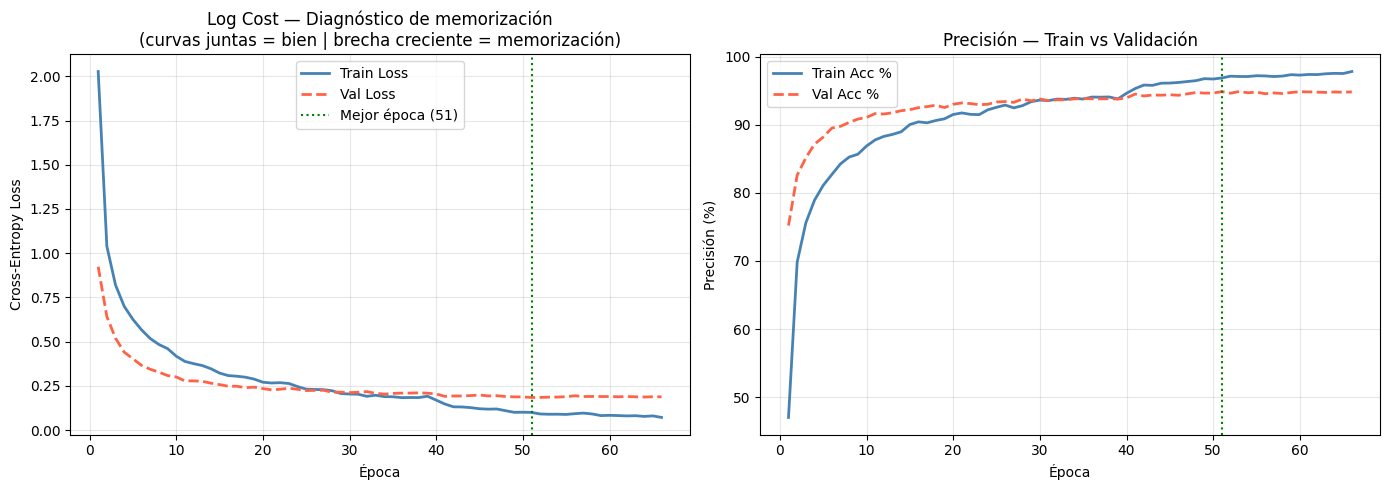


Diagnóstico del entrenamiento:
  Train loss final:  0.0715  |  Train acc: 97.81%
  Val   loss final:  0.1881  |  Val   acc: 94.82%
  Brecha (|val-train| loss): 0.1166
  ✓ Brecha aceptable — el modelo generalizó correctamente


In [19]:
# ── 5.1 Curvas de pérdida y precisión ────────────────────────────────────────
epocas = range(1, len(train_losses) + 1)

fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

# Log cost
axes[0].plot(epocas, train_losses, label='Train Loss', linewidth=2, color='steelblue')
axes[0].plot(epocas, val_losses,   label='Val Loss',   linewidth=2,
             color='tomato', linestyle='--')
axes[0].axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5,
                label=f'Mejor época ({best_epoch})')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Log Cost — Diagnóstico de memorización\n'
                  '(curvas juntas = bien | brecha creciente = memorización)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precisión
axes[1].plot(epocas, [a*100 for a in train_accs], label='Train Acc %',
             linewidth=2, color='steelblue')
axes[1].plot(epocas, [a*100 for a in val_accs],   label='Val Acc %',
             linewidth=2, color='tomato', linestyle='--')
axes[1].axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión (%)')
axes[1].set_title('Precisión — Train vs Validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

# ── Diagnóstico automático ────────────────────────────────────────────────────
brecha = abs(val_losses[-1] - train_losses[-1])
print(f'\nDiagnóstico del entrenamiento:')
print(f'  Train loss final:  {train_losses[-1]:.4f}  |  Train acc: {train_accs[-1]*100:.2f}%')
print(f'  Val   loss final:  {val_losses[-1]:.4f}  |  Val   acc: {val_accs[-1]*100:.2f}%')
print(f'  Brecha (|val-train| loss): {brecha:.4f}')
if brecha < 0.3:
    print('  ✓ Brecha aceptable — el modelo generalizó correctamente')
elif brecha < 0.8:
    print('  ⚠️  Brecha moderada — considerar más Dropout o menos épocas')
else:
    print('  ✗ Brecha grande — el modelo memorizó → entrenamiento MAL')

## Bloque 6 — Evaluación del Modelo

Se evalúa sobre el 20% de datos nunca vistos,  
comparando con los resultados del Lab 6 original.

In [20]:
# ── 6.1 Predicciones sobre el conjunto de prueba ─────────────────────────────
model.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1).cpu().numpy()
        preds   = torch.argmax(logits, dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = accuracy_score(all_labels, all_preds)

print(f"{'='*60}")
print('EVALUACIÓN — MODELO PYTORCH (conjunto de prueba 20%)')
print(f"{'='*60}")
print(f'Accuracy global: {accuracy:.4f}  ({accuracy*100:.2f} %)')
print()
print('Comparativa con Lab 6 original (One-vs-All):')
print(f'  Lab 6 — Precisión train: 83.01 %')
print(f'  Lab 6 — Precisión test:  65.73 %')
print(f'  PyTorch — Precisión test: {accuracy*100:.2f} %')

EVALUACIÓN — MODELO PYTORCH (conjunto de prueba 20%)
Accuracy global: 0.9486  (94.86 %)

Comparativa con Lab 6 original (One-vs-All):
  Lab 6 — Precisión train: 83.01 %
  Lab 6 — Precisión test:  65.73 %
  PyTorch — Precisión test: 94.86 %


In [21]:
# ── 6.2 Precisión por clase ───────────────────────────────────────────────────
print('Precisión por clase:')
print(f"{'Clase':>5}  {'Nombre':>18}  {'Acc':>8}")
print('-' * 36)

accs_por_clase = []
for c in range(num_labels):
    mask   = all_labels == c
    if mask.sum() > 0:
        acc_c = accuracy_score(all_labels[mask], all_preds[mask])
        accs_por_clase.append(acc_c)
        nombre = nombres_clases[c] if c < len(nombres_clases) else f'clase_{c}'
        print(f'{c:>5}  {nombre:>18}  {acc_c*100:>7.1f} %')

Precisión por clase:
Clase              Nombre       Acc
------------------------------------
    0                  ka     96.6 %
    1                 kha     96.4 %
    2                  ga     94.0 %
    3                 gha     97.9 %
    4                 kna     97.6 %
    5                 cha     87.8 %
    6                chha     96.8 %
    7                  ja     86.1 %
    8                 jha     97.3 %
    9                 yna     94.6 %
   10            taamatar     96.2 %
   11                thaa     96.9 %
   12                 daa     88.3 %
   13                dhaa     93.3 %
   14                adna     92.7 %
   15              tabala     88.0 %
   16                 tha     97.0 %
   17                  da     96.7 %
   18                 dha     92.4 %
   19                  na     94.5 %
   20                  pa     98.3 %
   21                 pha     95.6 %
   22                  ba     94.1 %
   23                 bha     92.7 %
   24             

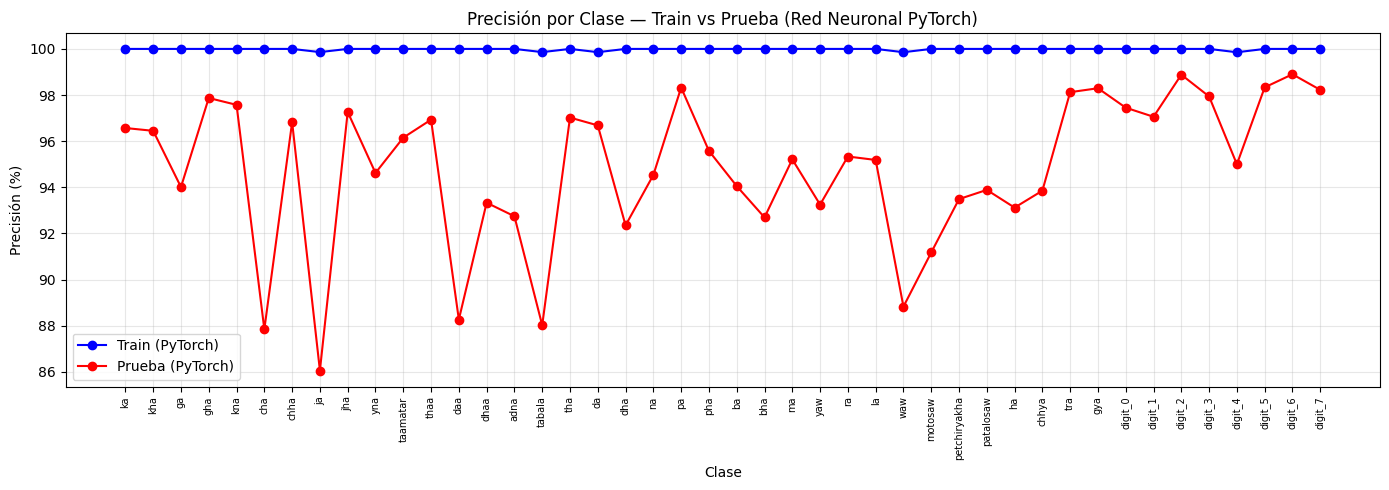

In [22]:
# ── 6.3 Gráfica de precisión por clase — igual que Lab 6 ─────────────────────
# Calcular precisión train y test por clase para comparar
model.eval()
all_preds_train = []
all_labels_train = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        preds   = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds_train.extend(preds)
        all_labels_train.extend(y_batch.numpy())

all_preds_train  = np.array(all_preds_train)
all_labels_train = np.array(all_labels_train)

precisiones_train_nn = []
precisiones_test_nn  = []

for c in range(num_labels):
    mask_tr = all_labels_train == c
    mask_te = all_labels == c
    acc_tr = accuracy_score(all_labels_train[mask_tr], all_preds_train[mask_tr]) if mask_tr.sum() > 0 else 0
    acc_te = accuracy_score(all_labels[mask_te], all_preds[mask_te]) if mask_te.sum() > 0 else 0
    precisiones_train_nn.append(acc_tr * 100)
    precisiones_test_nn.append(acc_te * 100)

pyplot.figure(figsize=(14, 5))
pyplot.plot(range(num_labels), precisiones_train_nn, 'bo-', label='Train (PyTorch)')
pyplot.plot(range(num_labels), precisiones_test_nn,  'ro-', label='Prueba (PyTorch)')
pyplot.xlabel('Clase')
pyplot.ylabel('Precisión (%)')
pyplot.title('Precisión por Clase — Train vs Prueba (Red Neuronal PyTorch)')
pyplot.xticks(range(num_labels),
              [nombres_clases[c] if c < len(nombres_clases) else str(c) for c in range(num_labels)],
              rotation=90, fontsize=7)
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

Precisión sobre 100 muestras aleatorias: 96.00 %


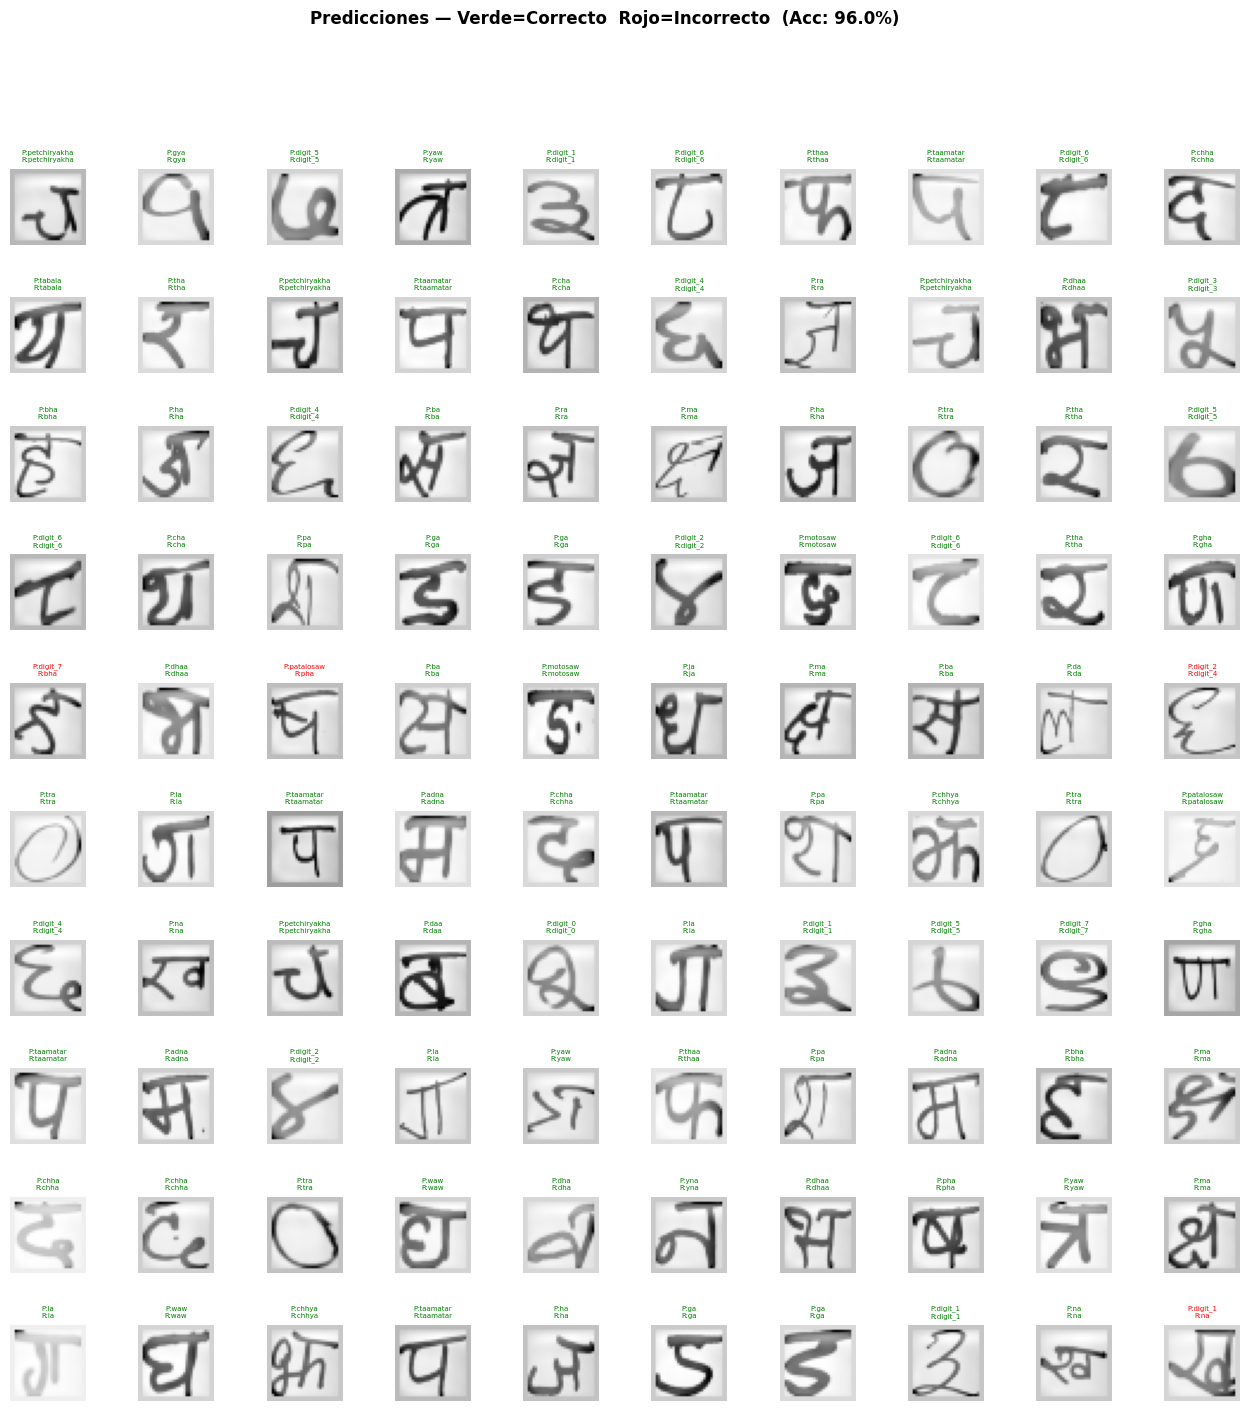

In [23]:
# ── 6.4 Visualización de 100 predicciones — igual que Lab 6 ──────────────────
rand_indices = np.random.choice(len(y_test), 100, replace=False)
X_vis  = X_test_norm[rand_indices]
y_real = y_test[rand_indices]

X_vis_t = torch.from_numpy(X_vis).float().to(device)

model.eval()
with torch.no_grad():
    logits_vis = model(X_vis_t)
    preds_vis  = torch.argmax(logits_vis, dim=1).cpu().numpy()

precision_100 = np.mean(preds_vis == y_real) * 100
print(f'Precisión sobre 100 muestras aleatorias: {precision_100:.2f} %')

fig, ax_array = pyplot.subplots(10, 10, figsize=(16, 16))
fig.subplots_adjust(wspace=0.5, hspace=0.7)
ax_array = ax_array.ravel()

for i, ax in enumerate(ax_array):
    ax.imshow(X_vis[i].reshape(32, 32), cmap='Greys')
    real_n = nombres_clases[int(y_real[i])]   if int(y_real[i])   < len(nombres_clases) else str(y_real[i])
    pred_n = nombres_clases[int(preds_vis[i])] if int(preds_vis[i]) < len(nombres_clases) else str(preds_vis[i])
    color  = 'green' if preds_vis[i] == y_real[i] else 'red'
    ax.set_title(f'P:{pred_n}\nR:{real_n}', fontsize=5, color=color)
    ax.axis('off')

pyplot.suptitle(f'Predicciones — Verde=Correcto  Rojo=Incorrecto  (Acc: {precision_100:.1f}%)',
                fontsize=12, fontweight='bold')
pyplot.show()

## Carga y Uso del Modelo Guardado (cuadernillo 04)

In [26]:
# ── 7.1 Funciones de deployment ──────────────────────────────────────────────
def cargar_modelo_devanagari(checkpoint_path, device):
    """Carga el modelo de reconocimiento Devanagari desde checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    n_classes = ckpt['num_classes']
    modelo = DevanagariClassifier(input_size=1024, num_classes=n_classes).to(device)
    modelo.load_state_dict(ckpt['model_state_dict'])
    modelo.eval()
    norm_params = ckpt['normalization_params']
    print(f'✓ Modelo cargado  (época {ckpt["epoch"]}, '
          f'val_acc={ckpt["val_acc"]*100:.2f}%)')
    return modelo, norm_params


def predecir_caracter(X_raw, modelo, norm_params, device):
    """Predice la clase de caracteres Devanagari."""
    X_norm = (X_raw - norm_params['mu']) / norm_params['sigma']
    X_t    = torch.from_numpy(X_norm).float().to(device)
    with torch.no_grad():
        logits = modelo(X_t)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = torch.argmax(logits, dim=1).cpu().numpy()
    return preds, probs


print('✓ Funciones de deployment definidas')

✓ Funciones de deployment definidas


In [27]:
# ── 7.2 Predicciones con modelo recargado ────────────────────────────────────
modelo_cargado, norm_params_cargados = cargar_modelo_devanagari(CHECKPOINT, device)

idx_muestra = np.random.choice(len(X_test_raw), size=5, replace=False)
X_muestra   = X_test_raw[idx_muestra]    # datos crudos SIN normalizar
y_muestra   = y_test[idx_muestra]

preds_m, probs_m = predecir_caracter(X_muestra, modelo_cargado,
                                      norm_params_cargados, device)

print(f"\n{'='*65}")
print('PREDICCIONES NUEVAS (modelo cargado desde checkpoint)')
print(f"{'='*65}")

for i in range(5):
    real_n = nombres_clases[int(y_muestra[i])]  if int(y_muestra[i])  < len(nombres_clases) else str(y_muestra[i])
    pred_n = nombres_clases[int(preds_m[i])]    if int(preds_m[i])    < len(nombres_clases) else str(preds_m[i])
    conf   = probs_m[i, int(preds_m[i])] * 100
    icono  = '✓' if preds_m[i] == y_muestra[i] else '✗'
    print(f'  Ejemplo {i+1}:  Real={real_n:>18}  Pred={pred_n:>18}  '
          f'Confianza={conf:.1f}%  {icono}')

✓ Modelo cargado  (época 51, val_acc=94.86%)

PREDICCIONES NUEVAS (modelo cargado desde checkpoint)
  Ejemplo 1:  Real=           digit_5  Pred=           digit_5  Confianza=99.9%  ✓
  Ejemplo 2:  Real=               dha  Pred=               dha  Confianza=97.3%  ✓
  Ejemplo 3:  Real=                ha  Pred=                ha  Confianza=100.0%  ✓
  Ejemplo 4:  Real=           digit_2  Pred=           digit_2  Confianza=100.0%  ✓
  Ejemplo 5:  Real=           digit_7  Pred=           digit_0  Confianza=43.9%  ✗


In [28]:
# ── Resumen final ─────────────────────────────────────────────────────────────
print('='*65)
print('RESUMEN FINAL')
print('='*65)
print(f'Dataset:          Devanagari Handwritten Characters')
print(f'Total ejemplos:   {m:,} (balanceados: 888 por clase)')
print(f'Clases:           {num_labels}')
print(f'Train:            {X_train_norm.shape[0]:,} (80%)')
print(f'Test:             {X_test_norm.shape[0]:,} (20%)')
print(f'Arquitectura:     1024 → 512 → 256 → 128 → {num_labels}')
print(f'Épocas totales:   {len(train_losses)}')
print(f'Mejor época:      {best_epoch}')
print(f'Val Loss (mejor): {best_val_loss:.4f}')
print(f'Accuracy test:    {accuracy*100:.2f} %')
print(f'Lab 6 baseline:   65.73 %')
print(f'Mejora:           +{accuracy*100 - 65.73:.2f} %')
print(f'Checkpoint:       {CHECKPOINT}')
print('='*65)

RESUMEN FINAL
Dataset:          Devanagari Handwritten Characters
Total ejemplos:   39,072 (balanceados: 888 por clase)
Clases:           44
Train:            31,257 (80%)
Test:             7,815 (20%)
Arquitectura:     1024 → 512 → 256 → 128 → 44
Épocas totales:   66
Mejor época:      51
Val Loss (mejor): 0.1842
Accuracy test:    94.86 %
Lab 6 baseline:   65.73 %
Mejora:           +29.13 %
Checkpoint:       best_devanagari_model.pth
